In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Input


RANDOM_STATE = 42


np.random.seed(
    RANDOM_STATE
)

tf.random.set_seed(
    RANDOM_STATE
)

In [2]:
CURRENT_DIR = Path.cwd()


if CURRENT_DIR.name == "notebooks":
    ROOT = CURRENT_DIR.parent
else:
    ROOT = CURRENT_DIR


DATA_PATH = (
    ROOT
    / "data"
    / "predictive_maintenance.csv"
)


MODEL_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "outputs"


MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)


print("Project root:", ROOT)

Project root: d:\Deep Learning\Anomaly Detection


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}"
    )


df = pd.read_csv(
    DATA_PATH
)


print(
    "Dataset shape:",
    df.shape
)


df.head()

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
FEATURES = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]


TARGET = "Machine failure"

In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df[TARGET],
)


normal_train_df = train_df[
    train_df[TARGET] == 0
].copy()


print(
    "Normal training records:",
    len(normal_train_df)
)


print(
    "Test records:",
    len(test_df)
)

Normal training records: 7729
Test records: 2000


In [6]:
scaler = StandardScaler()


X_normal = scaler.fit_transform(
    normal_train_df[FEATURES]
)


X_test = scaler.transform(
    test_df[FEATURES]
)


y_test = test_df[TARGET].to_numpy()


print(
    "Normal training shape:",
    X_normal.shape
)


print(
    "Test shape:",
    X_test.shape
)

Normal training shape: (7729, 5)
Test shape: (2000, 5)


In [7]:
X_ae_train, X_ae_val = train_test_split(
    X_normal,
    test_size=0.20,
    random_state=RANDOM_STATE,
)


print(
    "Autoencoder training:",
    X_ae_train.shape
)


print(
    "Autoencoder validation:",
    X_ae_val.shape
)

Autoencoder training: (6183, 5)
Autoencoder validation: (1546, 5)


In [8]:
input_dim = X_ae_train.shape[1]


autoencoder = Sequential([
    Input(
        shape=(input_dim,)
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        4,
        activation="relu",
        name="latent_space"
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        input_dim,
        activation="linear"
    ),
])


autoencoder.compile(
    optimizer="adam",
    loss="mse",
)


autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 537 (2.10 KB)

 Trainable params: 537 (2.10 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
)

In [10]:
history = autoencoder.fit(
    X_ae_train,
    X_ae_train,

    validation_data=(
        X_ae_val,
        X_ae_val
    ),

    epochs=100,
    batch_size=32,
    shuffle=True,

    callbacks=[
        early_stopping
    ],

    verbose=1,
)

Epoch 1/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6747 - val_loss: 0.3510
Epoch 2/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2784 - val_loss: 0.2399
Epoch 3/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1704 - val_loss: 0.0879
Epoch 4/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0679 - val_loss: 0.0548
Epoch 5/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0513 - val_loss: 0.0463
Epoch 6/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0457 - val_loss: 0.0430
Epoch 7/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0431 - val_loss: 0.0411
Epoch 8/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0415 - val_loss: 0.0401
Epoch 9/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0405 - val_loss: 0.0392
Epoch 10/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0398 - val_loss: 0.0387
Epoch 11/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0393 - val_loss: 0.0383
Epoch 12/100
194/194 ━━━━━━━━━━━━━━━━━━━━

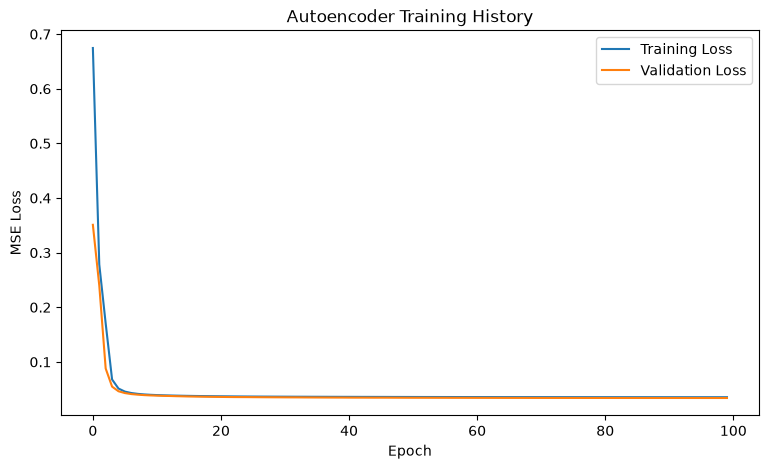

In [11]:
plt.figure(figsize=(9, 5))


plt.plot(
    history.history["loss"],
    label="Training Loss"
)


plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(
    "Autoencoder Training History"
)
plt.legend()
plt.show()

In [12]:
val_reconstruction = autoencoder.predict(
    X_ae_val,
    verbose=0,
)


val_errors = np.mean(
    np.square(
        X_ae_val
        - val_reconstruction
    ),
    axis=1,
)


threshold = np.percentile(
    val_errors,
    95
)


print(
    f"Autoencoder threshold: {threshold:.6f}"
)

Autoencoder threshold: 0.102761


In [13]:
test_reconstruction = autoencoder.predict(
    X_test,
    verbose=0,
)


test_errors = np.mean(
    np.square(
        X_test
        - test_reconstruction
    ),
    axis=1,
)


ae_predictions = (
    test_errors > threshold
).astype(int)


print(
    "Detected anomalies:",
    ae_predictions.sum()
)

Detected anomalies: 112


In [14]:
test_reconstruction = autoencoder.predict(
    X_test,
    verbose=0,
)


test_errors = np.mean(
    np.square(
        X_test
        - test_reconstruction
    ),
    axis=1,
)


ae_predictions = (
    test_errors > threshold
).astype(int)


print(
    "Detected anomalies:",
    ae_predictions.sum()
)

Detected anomalies: 112


In [15]:
ae_precision = precision_score(
    y_test,
    ae_predictions,
    zero_division=0,
)


ae_recall = recall_score(
    y_test,
    ae_predictions,
    zero_division=0,
)


ae_f1 = f1_score(
    y_test,
    ae_predictions,
    zero_division=0,
)


ae_auc = roc_auc_score(
    y_test,
    test_errors,
)


print(
    f"Precision : {ae_precision:.4f}"
)

print(
    f"Recall    : {ae_recall:.4f}"
)

print(
    f"F1 Score  : {ae_f1:.4f}"
)

print(
    f"ROC AUC   : {ae_auc:.4f}"
)

Precision : 0.1071
Recall    : 0.1765
F1 Score  : 0.1333
ROC AUC   : 0.6833


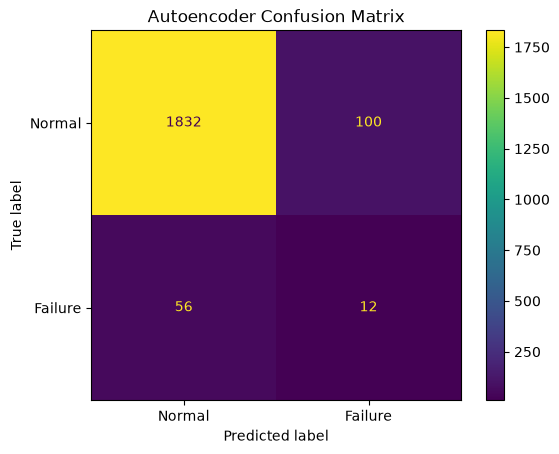

In [16]:
cm = confusion_matrix(
    y_test,
    ae_predictions
)


display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Failure"
    ]
)


display.plot()

plt.title(
    "Autoencoder Confusion Matrix"
)

plt.show()

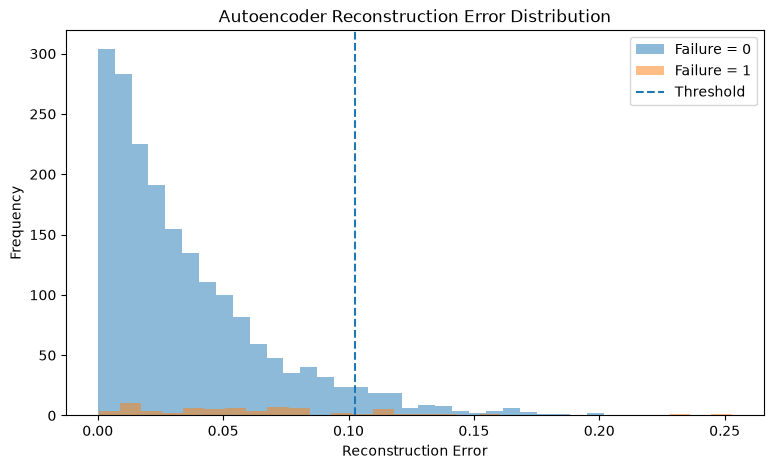

In [17]:
plt.figure(figsize=(9, 5))


for label in [0, 1]:

    subset_errors = test_errors[
        y_test == label
    ]

    plt.hist(
        subset_errors,
        bins=30,
        alpha=0.5,
        label=f"Failure = {label}"
    )


plt.axvline(
    threshold,
    linestyle="--",
    label="Threshold"
)


plt.xlabel(
    "Reconstruction Error"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Autoencoder Reconstruction Error Distribution"
)

plt.legend()
plt.show()

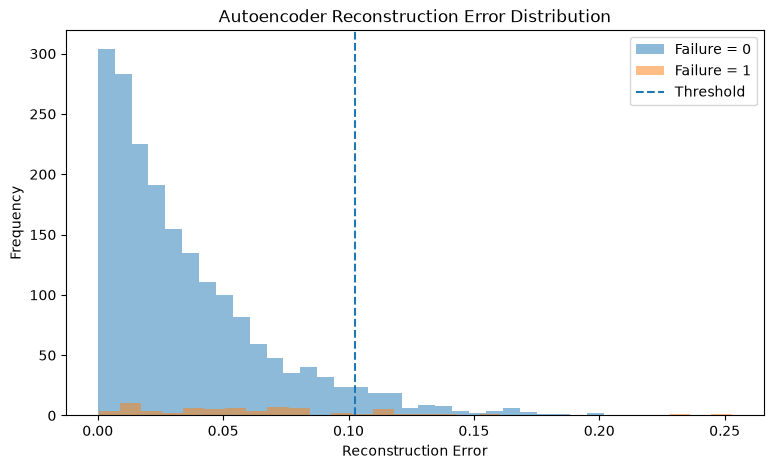

In [18]:
plt.figure(figsize=(9, 5))


for label in [0, 1]:

    subset_errors = test_errors[
        y_test == label
    ]

    plt.hist(
        subset_errors,
        bins=30,
        alpha=0.5,
        label=f"Failure = {label}"
    )


plt.axvline(
    threshold,
    linestyle="--",
    label="Threshold"
)


plt.xlabel(
    "Reconstruction Error"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Autoencoder Reconstruction Error Distribution"
)

plt.legend()
plt.show()

In [19]:
ae_results = test_df[
    [
        "UDI",
        "Product ID",
        TARGET
    ] + FEATURES
].copy()


ae_results[
    "ae_prediction"
] = ae_predictions


ae_results[
    "reconstruction_error"
] = test_errors


ae_results.sort_values(
    "reconstruction_error",
    ascending=False,
).head(20)

,UDI,Product ID,Machine failure,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],ae_prediction,reconstruction_error
7884,7885,L55064,1,300.8,312.4,1465,59.1,91,1,0.252906
8307,8308,M23167,1,298.7,310.1,1402,69.7,64,1,0.233142
420,421,M15280,0,297.3,308.3,1301,39.6,5,1,0.201915
7893,7894,L55073,0,300.9,312.7,1416,43.8,112,1,0.199628
8180,8181,M23040,0,299.7,311.2,1616,42.3,180,1,0.184670
7873,7874,L55053,0,300.7,312.4,1470,38.6,56,1,0.176118
7978,7979,L55158,0,301.2,312.4,1480,53.5,97,1,0.170768
4379,4380,M19239,0,301.8,309.5,1732,30.1,220,1,0.170120
4431,4432,H33845,0,302.3,310.2,1443,54.6,120,1,0.169420
4429,4430,M19289,0,302.3,310.1,1731,33.4,112,1,0.165927


In [20]:
autoencoder.save(
    MODEL_DIR / "autoencoder.keras"
)


joblib.dump(
    scaler,
    MODEL_DIR / "scaler.pkl"
)


metadata = {
    "autoencoder_threshold": float(
        threshold
    ),

    "features": FEATURES,
}


with open(
    MODEL_DIR / "metadata.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        metadata,
        file,
        indent=2,
    )


ae_results.to_csv(
    OUTPUT_DIR / "ae_test_predictions.csv",
    index=False,
)


print(
    "Autoencoder artifacts saved successfully."
)

Autoencoder artifacts saved successfully.
